In [ ]:
#kütüphaneleri yükle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
clean_data = pd.read_csv('cleaned_data.csv')
clean_data

,age,self_employed,family_history,treatment,remote_work,obs_consequence,gender_standardized,country_encoded,work_interfere_encoded,no_employees_encoded,...,seek_help_encoded,anonymity_encoded,leave_encoded,mental_health_consequence_encoded,phys_health_consequence_encoded,coworkers_encoded,supervisor_encoded,mental_health_interview_encoded,phys_health_interview_encoded,mental_vs_physical_encoded
0,46,1,1,0,1,1,1,9,2,0,...,2,1,3,0,0,1,1,0,1,1
1,29,0,1,1,0,0,1,9,2,3,...,0,0,1,2,0,2,2,0,0,0
2,31,1,0,0,1,0,1,9,0,0,...,0,1,1,0,0,2,2,0,2,1
3,46,0,0,1,1,0,1,9,3,2,...,0,2,4,2,0,2,1,0,2,0
4,33,0,1,1,0,0,1,9,1,2,...,1,1,4,0,0,1,1,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749,30,0,1,1,0,0,1,9,2,2,...,0,1,3,0,0,1,1,2,2,1
750,30,1,1,1,0,0,1,9,3,2,...,1,2,4,0,0,2,1,2,2,1
751,29,0,1,1,1,0,1,9,2,3,...,0,1,4,1,0,2,0,0,2,0
752,32,0,1,1,1,0,1,9,3,2,...,0,1,1,0,0,2,1,0,0,1


In [ ]:
#total sütun ve satır sayısı
clean_data.shape

(754, 23)

In [ ]:
clean_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype
---  ------                             --------------  -----
 0   age                                754 non-null    int64
 1   self_employed                      754 non-null    int64
 2   family_history                     754 non-null    int64
 3   treatment                          754 non-null    int64
 4   remote_work                        754 non-null    int64
 5   obs_consequence                    754 non-null    int64
 6   gender_standardized                754 non-null    int64
 7   country_encoded                    754 non-null    int64
 8   work_interfere_encoded             754 non-null    int64
 9   no_employees_encoded               754 non-null    int64
 10  benefits_encoded                   754 non-null    int64
 11  care_options_encoded               754 non-null    int64
 12  wellness_program_encod

In [ ]:
# Gender sütunundaki benzersiz değerleri ve sayılarını görme
gender_sütunundaki_veriler = clean_data['gender_standardized'].value_counts()
print(gender_sütunundaki_veriler)
#burada 1 değeri erkek 0 değeri kadın anlamına geliyor

gender_standardized
1    599
0    155
Name: count, dtype: int64


In [ ]:
# Gender sütunundaki null değerleri bulma
gender_sütunundaki_null_değerler = clean_data['gender_standardized'].isnull().sum()
print(f"'Gender' sütunundaki null değerlerin sayısı: {gender_sütunundaki_null_değerler}")

'Gender' sütunundaki null değerlerin sayısı: 0


In [ ]:
# Cinsiyet değerlerini düzenlemek için fonksiyon
def gender_düzenle(gender):
    if gender in [0]:
        return 'Female'
    elif gender in [1]:
        return 'Male'


# Cinsiyet sütununu güncelle
clean_data['gender_standardized'] = clean_data['gender_standardized'].apply(gender_düzenle)

# Cinsiyet değerlerini ve sayıları al
gender_sütunundaki_veriler = clean_data['gender_standardized'].value_counts()

# Toplam sayıları yazdır
toplam_kadın_sayısı = gender_sütunundaki_veriler.get('Female', 0)
toplam_erkek_sayısı = gender_sütunundaki_veriler.get('Male', 0)

print(f'Toplam kadın sayısı: {toplam_kadın_sayısı}')
print(f'Toplam erkek sayısı : {toplam_erkek_sayısı}')


Toplam kadın sayısı: 155
Toplam erkek sayısı : 599


<ipython-input-150-2ed6fd063081>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=gender_sütunundaki_veriler.index, y=gender_sütunundaki_veriler.values, palette='coolwarm')


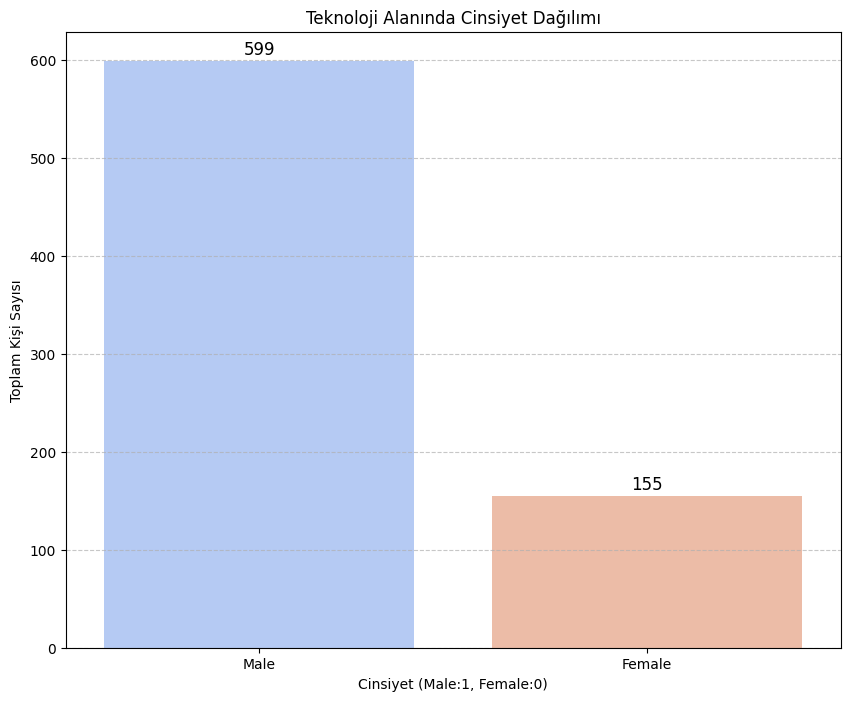

In [ ]:
# Grafik oluşturma
plt.figure(figsize=(10, 8))
ax = sns.barplot(x=gender_sütunundaki_veriler.index, y=gender_sütunundaki_veriler.values, palette='coolwarm')

# Her sütunun üstüne sayısal değerler ekleme
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.title('Teknoloji Alanında Cinsiyet Dağılımı')
plt.xlabel('Cinsiyet (Male:1, Female:0)')
plt.ylabel('Toplam Kişi Sayısı')
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Y ekseninde ızgara ekle
plt.xticks(rotation=0)
plt.show()



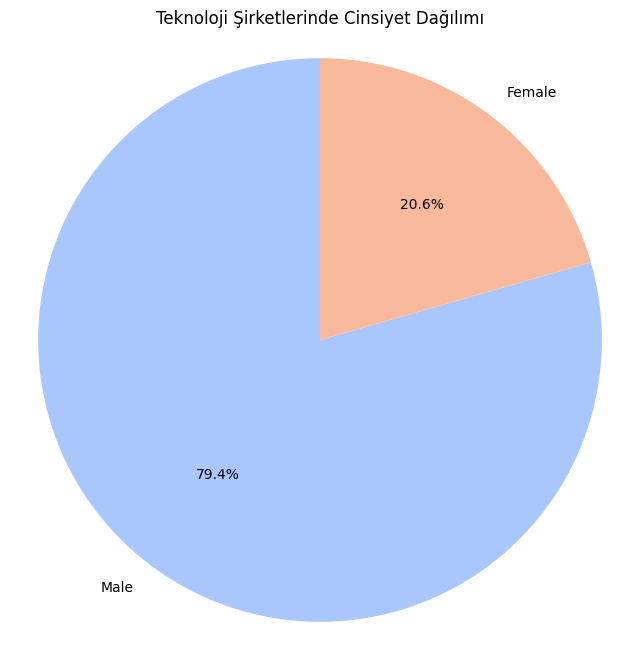

In [ ]:
# Cinsiyet verilerinin dağılımını görselleştirme (Pasta Grafiği)
gender_sütunundaki_veriler = clean_data['gender_standardized'].value_counts()
plt.figure(figsize=(8, 8))

# Coolwarm paletini kullanarak pasta grafiği oluşturma
colors = sns.color_palette("coolwarm", n_colors=len(gender_sütunundaki_veriler))
plt.pie(gender_sütunundaki_veriler, labels=gender_sütunundaki_veriler.index, autopct='%1.1f%%', colors=colors, startangle=90)

plt.title('Teknoloji Şirketlerinde Cinsiyet Dağılımı')
plt.axis('equal')  # Eşit daire oluşturur
plt.show()

In [ ]:
treatment_counts = clean_data['treatment'].value_counts()
treatment_counts
#1 yes 0 no

,count
treatment,
1,471
0,283


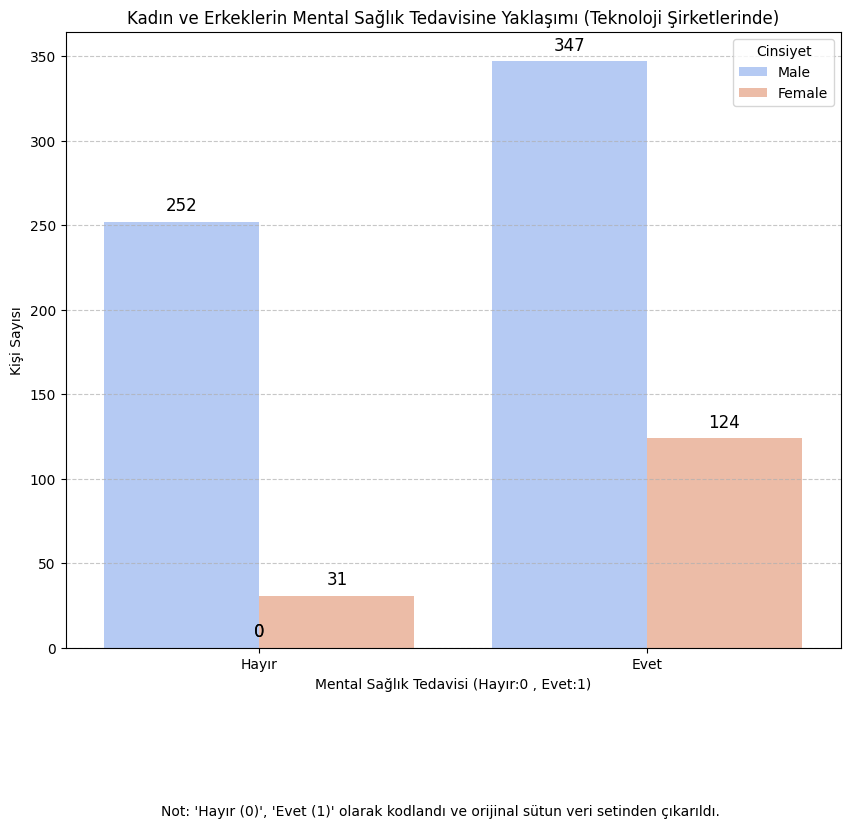

In [ ]:
# Mental sağlık tedavisine yaklaşımı görselleştirme
plt.figure(figsize=(10, 8))
ax = sns.countplot(x='treatment', hue='gender_standardized', data=clean_data, palette='coolwarm')

# Her çubuğun üstüne sayısal etiketler ekleme
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.title('Kadın ve Erkeklerin Mental Sağlık Tedavisine Yaklaşımı (Teknoloji Şirketlerinde)')
plt.xlabel('Mental Sağlık Tedavisi (Hayır:0 , Evet:1)')
plt.xticks(ticks=[0, 1], labels=['Hayır', 'Evet'])
plt.ylabel('Kişi Sayısı')
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Y ekseninde ızgara ekle
plt.legend(title='Cinsiyet')

# Ek bilgi
plt.figtext(0.5, -0.1, "Not: 'Hayır (0)', 'Evet (1)' olarak kodlandı ve orijinal sütun veri setinden çıkarıldı.", ha='center', fontsize=10, wrap=True)

plt.show()


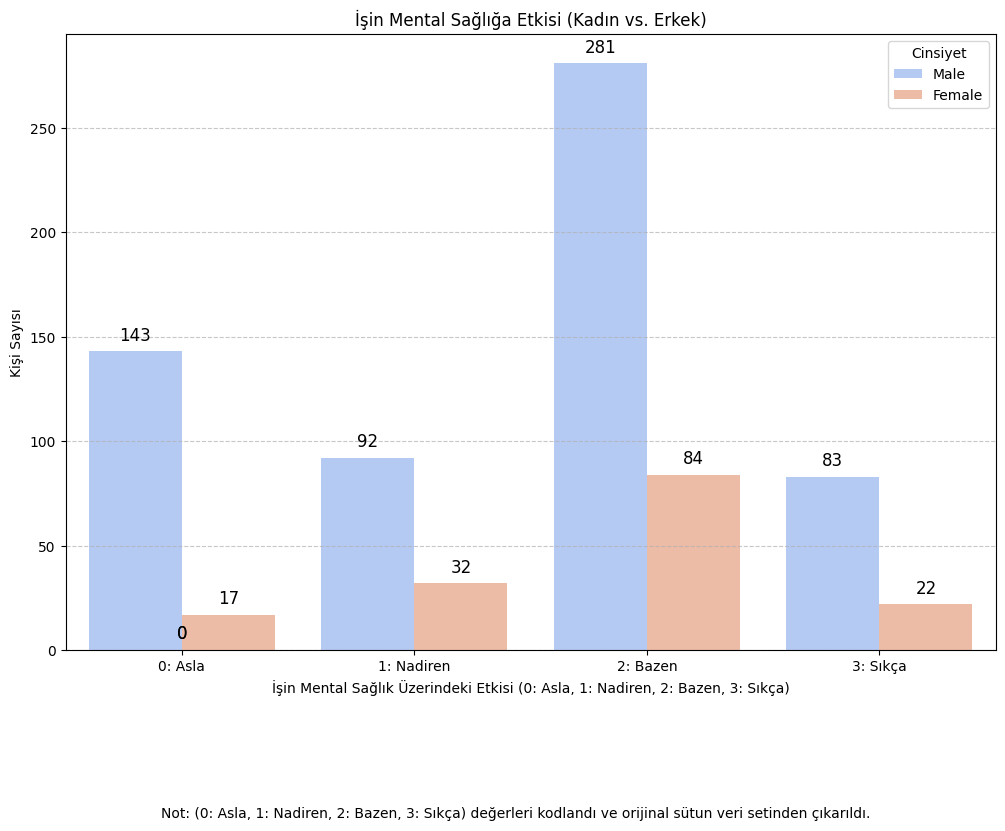

In [ ]:
# İşin mental sağlığa etkisini görselleştirme
plt.figure(figsize=(12, 8))
ax = sns.countplot(x='work_interfere_encoded', hue='gender_standardized', data=clean_data, palette='coolwarm')

# Her çubuğun üstüne sayısal etiketler ekleme
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.title('İşin Mental Sağlığa Etkisi (Kadın vs. Erkek)')
plt.xlabel('İşin Mental Sağlık Üzerindeki Etkisi (0: Asla, 1: Nadiren, 2: Bazen, 3: Sıkça)')
plt.xticks(ticks=[0, 1, 2, 3], labels=['0: Asla', '1: Nadiren', '2: Bazen', '3: Sıkça'])
plt.ylabel('Kişi Sayısı')
plt.legend(title='Cinsiyet')

plt.grid(axis='y', linestyle='--', alpha=0.7)  # Y ekseninde ızgara ekle

# Ek bilgi
plt.figtext(0.5, -0.1, "Not: (0: Asla, 1: Nadiren, 2: Bazen, 3: Sıkça) değerleri kodlandı ve orijinal sütun veri setinden çıkarıldı.",
            ha='center', fontsize=10, wrap=True)

plt.show()

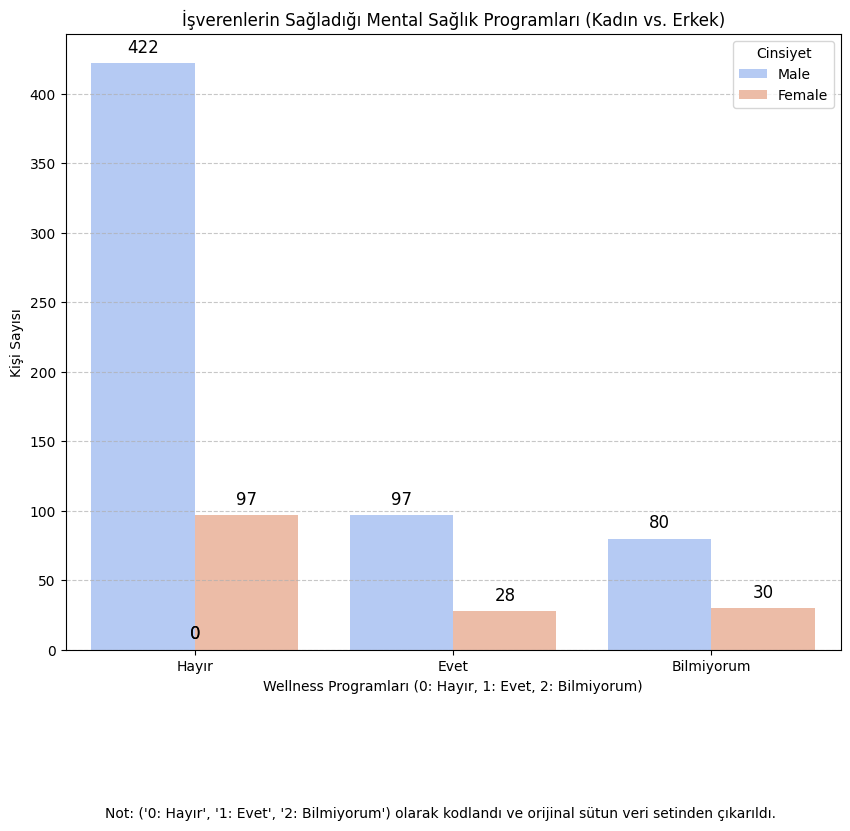

In [ ]:
# İşverenlerin sağladığı mental sağlık programlarını görselleştirme
plt.figure(figsize=(10, 8))
ax = sns.countplot(x='wellness_program_encoded', hue='gender_standardized', data=clean_data, palette='coolwarm')

# Her çubuğun üstüne sayısal etiketler ekleme
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black',
                xytext=(0, 5), textcoords='offset points')

plt.title('İşverenlerin Sağladığı Mental Sağlık Programları (Kadın vs. Erkek)')
plt.xlabel('Wellness Programları (0: Hayır, 1: Evet, 2: Bilmiyorum)')
plt.xticks(ticks=[0, 1, 2], labels=['Hayır','Evet', 'Bilmiyorum'])
plt.ylabel('Kişi Sayısı')
plt.legend(title='Cinsiyet')

plt.grid(axis='y', linestyle='--', alpha=0.7)  # Y ekseninde ızgara ekle

# Ek bilgi
plt.figtext(0.5, -0.1, "Not: ('0: Hayır', '1: Evet', '2: Bilmiyorum') olarak kodlandı ve orijinal sütun veri setinden çıkarıldı.",
            ha='center', fontsize=10, wrap=True)

plt.show()